# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print()
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

En el caso de users la columna city cuenta con 469 valores nulos, representando un 11,72% y la columna churn_date tiene 3534 valores nulos, representando un 88,35%.

Para el caso de churn_date, se ignorará la columna para el análisis. en el caso de la columna city, se investiga para imputar los datos de ser necesario.

En cuanto a usage, en la columna duration cuenta con 22076 valores nulos, representando un 55,19% y la columna length tiene 17896 valores nulos con un 44,74%.

Para los dos casos de las columnas presentadas en usage, con valores nulos se investiga, para identificar la causa de su ausencia. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
print(users['user_id'].describe())
print()
print(users['age'].describe())


count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


- La columna `user_id`, se identifica como una variable identificadora, se encuentran 4000 registros sin valores nulos, con registros desde el 10000 hasta 13999.
- La columna `age`, no cuenta con valores nulos, sin embargo, presenta un valor mínimo -999, lo que representa un error, afectando las estadísticas, presentando una desviación estándar de 123,23, muy alta para una variable de edad y la media también se ve afectada por este valor (33,74).

In [13]:
# explorar columnas numéricas de usage
print(usage['id'].describe())
print()
print(usage['user_id'].describe())

count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64


- Las columnas `id` y `user_id`, son identificadores, en ningún de los dos se presenta valores nulos, id van de 1 a 40.000 y user_id representa que hay 4.000 usuarios diferentes.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city`, cuenta con 3.531 registros, tiene 7 ciudades, la que más se repita es Bogotá con 808 repeticiones, de lo que se percibe que cuenta con valores vacíos.
- La columna `plan`, hay 4.000 registros, con 2 tipos de plan, el mas frecuente con 2.595 registros es Plan Basico.

In [15]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type`, es una variable con 40.000 registros, 2 tipos, con 22.092 registros de tipo text.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Se encuentras valores inválidos en la columna age de la base de datos users, valores que se remplazaran por la mediana, con el fin de no afectar las estadísticas de esta variable.

En la columna city se encuentran valores inválidos de la base de datos users, los cuales se remplazarán por valores nulos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users.reg_date, errors = "coerce")
users['reg_date'].dtype

print(users.dtypes)
print()
print(users.isna().sum())

user_id                int64
first_name            object
last_name             object
age                    int64
city                  object
reg_date      datetime64[ns]
plan                  object
churn_date            object
dtype: object

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] =  pd.to_datetime(usage.date, errors = "coerce")
usage['date'].dtype

print(usage.dtypes)
print()
print(usage.isna().sum())

id                   int64
user_id              int64
type                object
date        datetime64[ns]
duration           float64
length             float64
dtype: object

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


In [18]:
# Revisar los años presentes en `reg_date` de users
users['year'] = users.reg_date.dt.year
print (users['year'].unique())

[2022 2026 2023 2024]


En `reg_date`, se cuenta con 4 años 2022, 2023, 2024, los cuales son válidos, sin embargo, aparece el año 2026, el cual se considera invalido, ya que es una fecha futura.

In [19]:
# Revisar los años presentes en `date` de usage
usage['year'] = usage.date.dt.year
print (usage['year'].unique())

[2024.   nan]


En `date`, se encuentra el año 2024 y valores faltantes (nan). 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

En la columna date, aparecen años sin transcurrir (2026) y serán remplazados por valores nulos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, pd.NA)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:

# Marcar fechas futuras como NA para reg_date
users['year'] = users['year'].replace(2026, pd.NA)

# Verificar cambios
print (users['year'].dtype)
print ()
print (users['year'].describe())
print ()
print (users['year'].unique())

object

count     3960
unique       3
top       2024
freq      1330
Name: year, dtype: int64

[2022 <NA> 2023 2024]


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`

Los valores tanto de las columnas duration y length son MAR, ya que son nulos debido a que dependen de la columna type, debido a que los mensajes de texto no cuentan con duración de llamada (duration) y las llamadas no tienen longitud de texto (length).

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage["min"] = (usage["duration"].fillna(0).astype(float))

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,id,duration,length,year,is_text,is_call,min
0,10000,236778,23.70,258.0,20240.0,7,3,23.70
1,10001,296458,33.18,226.0,30360.0,5,10,33.18
2,10002,111444,10.74,225.0,14168.0,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename (columns = {"is_text": "cant_mensajes", "is_call": "cant_llamadas", "min": "cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,id,duration,length,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,236778,23.70,258.0,20240.0,7,3,23.70
1,10001,296458,33.18,226.0,30360.0,5,10,33.18
2,10002,111444,10.74,225.0,14168.0,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on = ['user_id'], how = 'inner')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year_x,id,duration,length,year_y,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,236778,23.70,258.0,20240.0,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,296458,33.18,226.0,30360.0,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,111444,10.74,225.0,14168.0,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,289686,8.99,530.0,28336.0,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,199943,8.01,229.0,14168.0,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:

# Resumen estadístico de las columnas numéricas
print (user_profile['age'].describe())
print ()
print (user_profile['cant_mensajes'].describe())
print ()
print (user_profile['cant_llamadas'].describe())
print ()
print (user_profile['cant_minutos_llamada'].describe())


count    3999.000000
mean       48.138285
std        17.691541
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64

count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64

count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64


In [29]:
# Distribución porcentual del tipo de plan
porcentajes = user_profile["plan"].value_counts(normalize=True) * 100
print (porcentajes)


Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

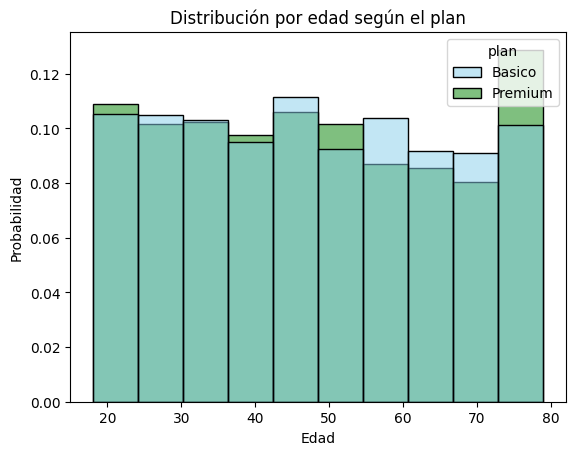

In [30]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=10, stat='probability', common_norm=False, palette=['skyblue', 'green'], edgecolor='black')

plt.xlabel('Edad')
plt.ylabel('Probabilidad')
plt.title('Distribución por edad según el plan')

plt.show()

💡Insights: 
- En el histograma que compara la distribución de las edades entre usuarios de los dos planes Basico y Premium, se evidencia que los dos planes muestran distribuciones similares, sin presentarse una concentración fuerte en algún rango de edad, lo que se sugiere que la edad no esta asociada con la elección del plan.
En el rango de 20 años, el plan básico presenta una probabilidad un poco mayor, al igual que los 45 años, donde se observa el pico más alto y en el extremo de edad de 75 a 80 años, el plan premium tiene su pico más alto.


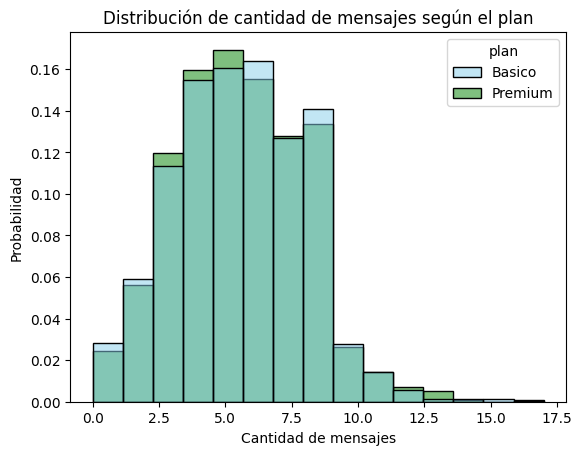

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=15, stat='probability', common_norm=False, palette=['skyblue', 'green'], edgecolor='black')

plt.xlabel('Cantidad de mensajes')
plt.ylabel('Probabilidad')
plt.title('Distribución de cantidad de mensajes según el plan')

plt.show()

💡Insights: 
- En cuanto a la cantidad de mensajes por tipo de plan, las dos distribuciones tienen asimetría a la derecha, ya que la mayoría de los usuarios presentan un envio de mensajes de 3 a 9, con una cola hacia la derecha, representando pocos usuarios enviando más de 10 mensajes.

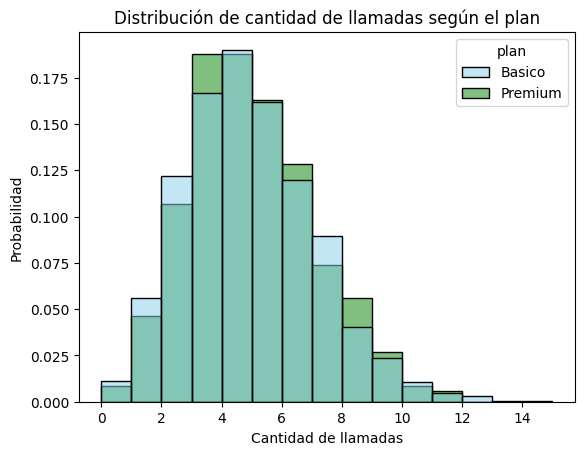

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=15, stat='probability', common_norm=False, palette=['skyblue', 'green'], edgecolor='black')

plt.xlabel('Cantidad de llamadas')
plt.ylabel('Probabilidad')
plt.title('Distribución de cantidad de llamadas según el plan')

plt.show()


💡Insights: 
- Con respecto al histograma sobre la cantidad de llamadas según el plan, la distribución es asimetría a la derecha, presentando una cola hacia valores altos, la mayoría de los datos se concentran entre 2 y 7 llamadas.
Se presenta un pico en el plan premium entre 3 y 4 llamadas y en plan básico se presenta mayor peso entre 7 y 8 llamadas.

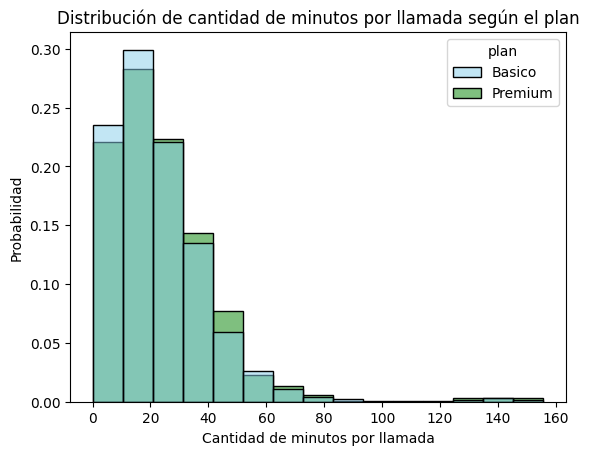

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=15, stat='probability', common_norm=False, palette=['skyblue', 'green'], edgecolor='black')

plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Probabilidad')
plt.title('Distribución de cantidad de minutos por llamada según el plan')

plt.show()


💡Insights: 
- La distribución de la cantidad de minutos por llamada esta sesgada a la derecha, sin mostrar mayor diferencia entre los dos planes, la mayoría de llamadas duras entre 0 y 40 minutos, en la cola se presentan unas pequeñas columnas representado entre 130 y 150 minutos, visibles que podrían indicar llamadas especiales.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

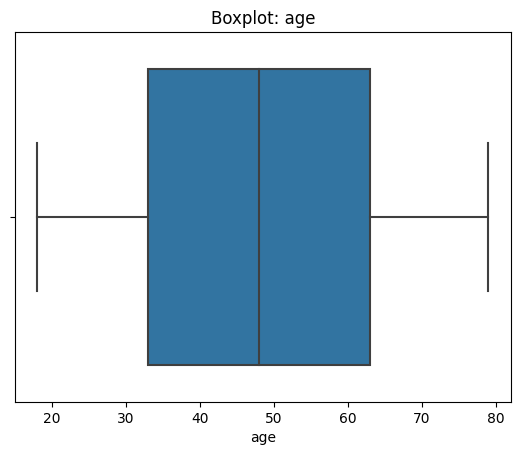

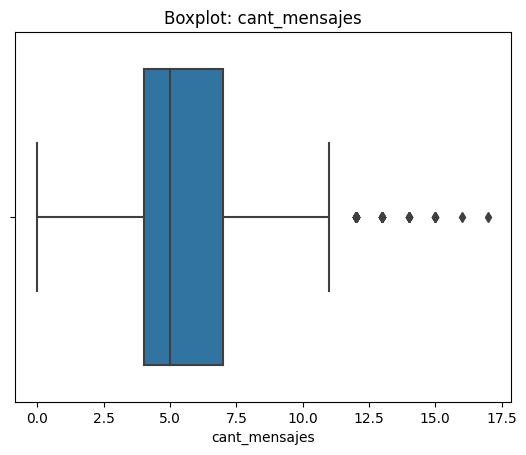

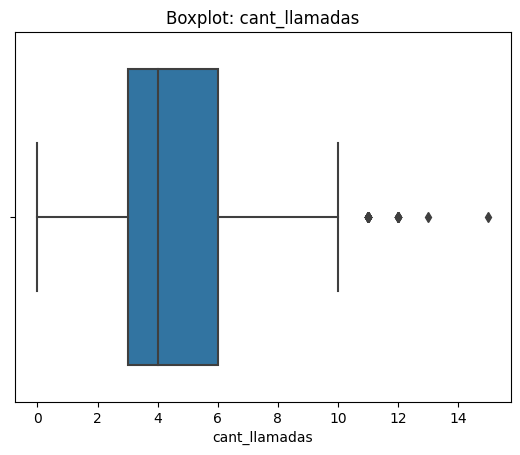

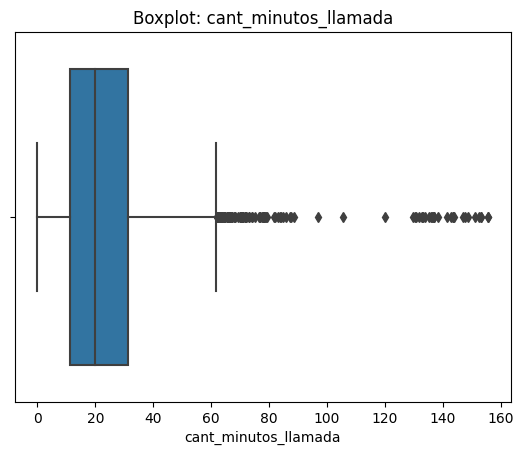

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:

    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers.
- cant_mensajes: Presenta outliers a la derecha, entre 12 y 17 mensajes.
- cant_llamadas: Presenta outliers a la derecha, entre 11 y 15 llamadas.
- cant_minutos_llamada: Presenta outliers, hay puntos en 60, 90 y entre 130 y 150 minutos presentando comportamiento atípico.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for lim in columnas_limites:
    
    Q1 = user_profile[lim].quantile(0.25)
    Q3 = user_profile[lim].quantile(0.75)
    IQR = Q3-Q1
    limite_superior = Q3+1.5*IQR

    print(limite_superior)

11.5
10.5
61.8575


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

En los 3 casos, se mantienen los outliers, porque pueden representar clientes especiales que están generando uso adicional de los servicios ofrecidos, lo que genera mayores ingresos a ConnectaTel.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:

# Crear columna grupo_uso
def grupo_uso (row):
    llamadas = row ['cant_llamadas']
    mensajes = row ['cant_mensajes']

    if llamadas < 5 and mensajes < 5:
            return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
            return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply (grupo_uso, axis =1)


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year_x,id,duration,length,year_y,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,236778,23.70,258.0,20240.0,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,296458,33.18,226.0,30360.0,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,111444,10.74,225.0,14168.0,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,289686,8.99,530.0,28336.0,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,199943,8.01,229.0,14168.0,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:** Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad

def grupo_edad (row):
    edad = row ['age']

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply (grupo_edad, axis =1)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year_x,id,duration,length,year_y,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,236778,23.70,258.0,20240.0,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,296458,33.18,226.0,30360.0,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,111444,10.74,225.0,14168.0,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,289686,8.99,530.0,28336.0,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,199943,8.01,229.0,14168.0,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

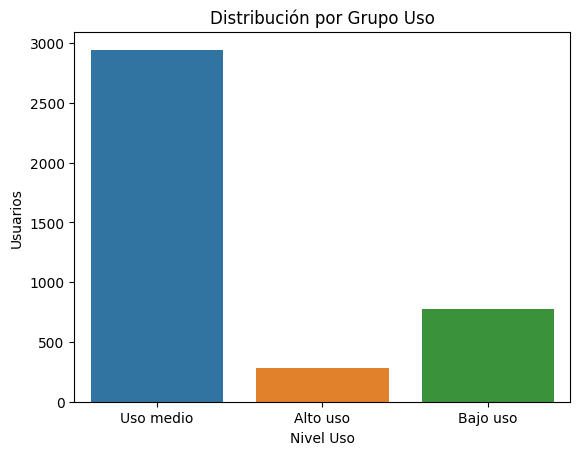

In [41]:
# Visualización de los segmentos por uso
sns.countplot(data = user_profile, x = 'grupo_uso')
plt.title ('Distribución por Grupo Uso')
plt.xlabel ('Nivel Uso')
plt.ylabel ('Usuarios')
plt.show()

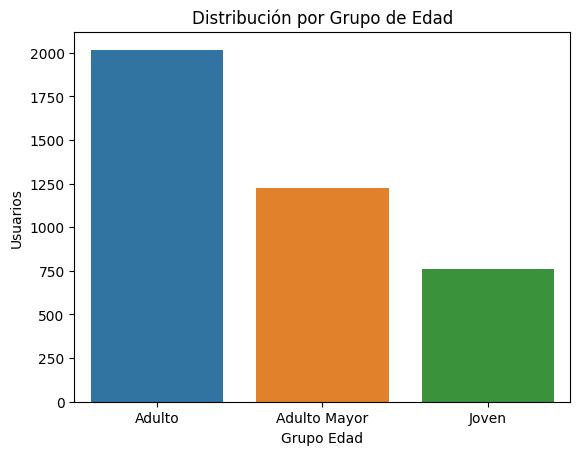

In [42]:
# Visualización de los segmentos por edad
sns.countplot(data = user_profile, x = 'grupo_edad')
plt.title ('Distribución por Grupo de Edad')
plt.xlabel ('Grupo Edad')
plt.ylabel ('Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmente los datos? ¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

En el caso de la base de datos users la columna city presentaba 469 valores nulos, representando un 11,72% y la columna churn_date tiene 3534 valores nulos, representando un 88,35%.

En cuanto a la base de datos usage, la columna duration cuenta con 22076 valores nulos, representando un 55,19% y la columna length tiene 17896 valores nulos con un 44,74%.

Se identifican dos segmentos de clientes, el primero por Nivel de uso (Bajo uso, Uso medio y Alto uso), el nivel de Uso medio tiene una representación mucho mayor, acercándose a los 3.000 usuarios, comparada con los otros dos segmentos de nivel de uso.

En el segmento por edad (Joven, Adulto y Adulto Mayor), los Adultos tienen mayor representación, representando más de 2.000 usuarios comparada con los otros segmentos.

Los segmentos con mayor representación son Nivel de Uso medio con un 73%, y Adulto con un 50%, lo que sugiere que ConnectaTel debe enfocarse en planes de fidelización para usuarios que envían entre 5 y 9 mensajes y realizan entre 5 y 9 llamadas y que se encuentran entre los 30 y los 59 años, y generar publicidad que atraiga al segmento Joven, menores de 30 con el fin de aumentar el numero de usuarios en esta categoría.

Se encuentran valores extremos en la cantidad de mensajes, entre 12 y 17 mensaje, la cantidad de llamadas, entre 11 y 15 llamadas y la cantidad de minutos por llamada donde se presentan puntos en 60, 90 y entre 130 y 150 minutos presentando comportamiento atípico.

Estos valores no se pueden ignorar, ni ser remplazados, porque se puede tratar de clientes especiales, con necesidades especificas a los que se les debe dar un trato diferencial, ya que esto implica mayor necesidad de servicios, aunque sea en un grupo muy pequeño, al que hay que impactar.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En el caso de la base de datos users la columna city presentaba 469 valores nulos, representando un 11,72%
- En cuanto a la columna duration cuenta con 22076 valores nulos, representando un 55,19% y la columna length tiene 17896 valores nulos con un 44,74%, que se debían analizar, con el fin de tomar una determinación frente a estos.
- Para Age, se presentaba un valor mínimo -999, lo que indicaba un error, afectando las estadísticas, con una desviación estándar de 123,23, muy alta para una variable de edad y las media también se puede ver afectada por este valor (33,74).

🔍 **Segmentos por Edad**
- Los Adultos con 2.000 usuarios representan el 50% del total.
- Los Adultos Mayores con 1.250 usuarios representan el 31% del total.
- Los Jóvenes con 750 usuarios representan el 19% del total 

📊 **Segmentos por Nivel de Uso**
- El Nivel de Uso Medio representa el 73% del uso en total.
- El Nivel Bajo Uso representa el 20% del uso en total.
- El Nivel Alto Uso representa el 8% del uso en total

➡️ Esto sugiere que, los segmentos con mayor representación son Nivel de Uso medio con un 73%, y en cuanto a Edad, los Adulto con un 50%, lo que evidencia usuarios que envían entre 5 y 9 mensajes y realizan entre 5 y 9 llamadas y se encuentran entre los 30 y los 59 años.

💡 **Recomendaciones**
- ConnectaTel debe enfocarse en planes de fidelización para usuarios de Nivel de Uso Medio y que se encuentran en la categoría Adulto.
- ConnectaTel debe generar publicidad que atraiga al segmento Joven, menores de 30 con el fin de aumentar el número de usuarios en esta categoría.
Investigar clientes especiales (grupo muy pequeño) con mayor necesidad de servicios (cantidad de mensajes, cantidad de llamadas y cantidad de minutos), a los que se les debe dar un trato diferencial, ya que deben ser impactados, debido a que, aunque son pocos, generan ingresos representativos a ConnectaTel.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`